Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Clique Cover

Given an undirected graph G = (V, E) and n colours, assign a colour to each
vertex. The clique cover problem asks: does each set of same-coloured vertices
form a clique (i.e. a complete subgraph)?

This is NP-complete. 

1. First penalty term: each vertex gets exactly one colour (subset W)
2. Second term: for each colour, the number of edges among vertices of that
  colour must equal the maximum possible (i.e. they form a complete subgraph)

H = 0 iff the colouring is a valid clique cover.

Decision variables: x_{v,i} = 1 if vertex v has colour i, else 0.
Total spins: n * N (n colours, N vertices).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from helpers.helpers import generate_adjacency_matrix_undirected

In [2]:
# ---- Hamiltonian Penalty Terms ----

def get_ha(x, A):
    """Each vertex must have exactly one colour.
    x is N x n_colours. Penalise if row sum != 1."""
    N = x.shape[0]
    ha = 0
    for v in range(N):
        row_sum = np.sum(x[v])
        ha += (1 - row_sum) ** 2
    return A * ha

def get_hb(x, adjacency_matrix, B):
    """For each colour, the coloured vertices must form a clique.
    Count how many edges are missing among same-coloured vertices."""
    N, n_colours = x.shape
    hb = 0
    for i in range(n_colours):
        # number of vertices with colour i
        colour_sum = np.sum(x[:, i])
        # max possible edges among them
        max_edges = 0.5 * (colour_sum - 1) * colour_sum
        # actual edges among them
        actual_edges = 0
        for u in range(N):
            for v in range(u + 1, N):
                if adjacency_matrix[u, v] == 1:
                    actual_edges += x[u, i] * x[v, i]
        hb += max_edges - actual_edges
    return B * hb

def calc_energy(x, adjacency_matrix, A, B):
    return get_ha(x, A) + get_hb(x, adjacency_matrix, B)

In [3]:
# ---- Metropolis / Simulated Annealing ----

def annealing(x, adjacency_matrix, A, B, T_start, steps):
    x = x.copy()
    energy = calc_energy(x, adjacency_matrix, A, B)
    best_x = x.copy()
    best_energy = energy

    N, n_colours = x.shape

    for step in range(steps):
        # flip a random spin in the N x n_colours matrix
        v = np.random.randint(0, N)
        c = np.random.randint(0, n_colours)
        x[v, c] = 1 - x[v, c]

        new_energy = calc_energy(x, adjacency_matrix, A, B)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_x = x.copy()
        else:
            x[v, c] = 1 - x[v, c]

    return best_x, best_energy

In [4]:
# ---- Verification ----

def verify_clique_cover(x, adjacency_matrix):
    """Check that each colour class forms a clique."""
    N, n_colours = x.shape

    # check each vertex has exactly one colour
    for v in range(N):
        assigned = np.sum(x[v])
        if assigned != 1:
            print(f"  Vertex {v} has {int(assigned)} colours (should be 1)")
            return False

    # check each colour class is a clique
    valid = True
    for i in range(n_colours):
        members = [v for v in range(N) if x[v, i] == 1]
        if len(members) <= 1:
            continue
        for a in range(len(members)):
            for b in range(a + 1, len(members)):
                if adjacency_matrix[members[a], members[b]] == 0:
                    print(f"  Colour {i}: vertices {members[a]} and {members[b]} are not connected")
                    valid = False
    if valid:
        colour_groups = {}
        for i in range(n_colours):
            members = [v for v in range(N) if x[v, i] == 1]
            if members:
                colour_groups[i] = members
        print(f"VALID clique cover with {len(colour_groups)} colours: {colour_groups}")
    else:
        print(f"INVALID clique cover")
    return valid

In [5]:
# ---- Plotting ----

def plot_clique_cover(adjacency_matrix, x):
    N, n_colours = x.shape
    G = nx.from_numpy_array(adjacency_matrix)
    pos = nx.spring_layout(G, seed=42)

    cmap = plt.cm.Set1(np.linspace(0, 1, n_colours))

    # assign colour to each vertex
    node_colours = []
    for v in range(N):
        assigned = np.where(x[v] == 1)[0]
        if len(assigned) == 1:
            node_colours.append(cmap[assigned[0]])
        else:
            node_colours.append('gray')

    plt.figure(figsize=(6, 6))
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1)

    # draw clique edges per colour group
    for i in range(n_colours):
        members = [v for v in range(N) if x[v, i] == 1]
        if len(members) > 1:
            clique_edges = [(u, v) for u in members for v in members
                            if u < v and adjacency_matrix[u, v] == 1]
            nx.draw_networkx_edges(G, pos, edgelist=clique_edges,
                                   edge_color=[cmap[i]], width=2.5)

    nx.draw_networkx_nodes(G, pos, node_color=node_colours, node_size=500,
                           edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=12)

    used = sum(1 for i in range(n_colours)
               if any(x[v, i] == 1 for v in range(N)))
    plt.title(f"Clique Cover ({used} colours used)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# ---- Small graph ----
# 0-1, 0-2, 1-2 (triangle), 3-4 (edge), 2-3
# Clique cover with 3 colours: {0,1,2}, {3,4} needs 3-4 edge... 
# Let's use: 0-1, 0-2, 1-2, 3-4
# Clique cover: colour 0 = {0,1,2} (triangle), colour 1 = {3,4} (edge)

adjacency_matrix = np.array([
    [0, 1, 1, 0, 0],
    [1, 0, 1, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 1, 0]
], dtype=np.int64)

N = len(adjacency_matrix)
n_colours = 3  # try with 3 colours
A = 5.0
B = 1.0
T_start = 5.0
steps = 200000

print(f"Graph: {N} vertices, {n_colours} colours available")
print("Edges: 0-1, 0-2, 1-2, 3-4")
print("Expected: {0,1,2} is a clique, {3,4} is a clique")

Graph: 5 vertices, 3 colours available
Edges: 0-1, 0-2, 1-2, 3-4
Expected: {0,1,2} is a clique, {3,4} is a clique


Energy: 0.0 (H=0 means valid clique cover)
H_A: 0.0
H_B: 0.0
VALID clique cover with 3 colours: {0: [1], 1: [3, 4], 2: [0, 2]}


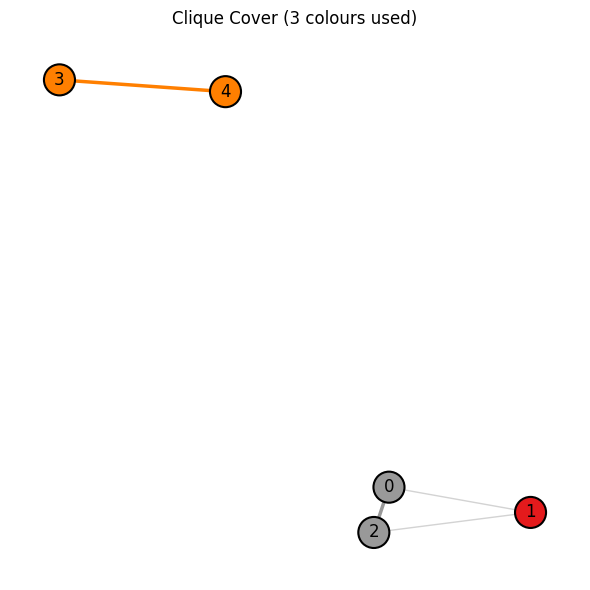

In [7]:
x = np.random.randint(2, size=(N, n_colours))
best_x, best_energy = annealing(x, adjacency_matrix, A, B, T_start, steps)

print(f"Energy: {best_energy} (H=0 means valid clique cover)")
print(f"H_A: {get_ha(best_x, A)}")
print(f"H_B: {get_hb(best_x, adjacency_matrix, B)}")
verify_clique_cover(best_x, adjacency_matrix)
plot_clique_cover(adjacency_matrix, best_x)

x [[1 1 0 1 1]
 [1 0 1 0 1]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 1 1 1]
 [1 0 0 0 0]
 [0 0 1 0 0]
 [0 0 1 0 1]]
Energy: 1.0
H_A (should be 0): 0.0
H_B (should be 0): 1.0
  Colour 3: vertices 5 and 9 are not connected
INVALID clique cover


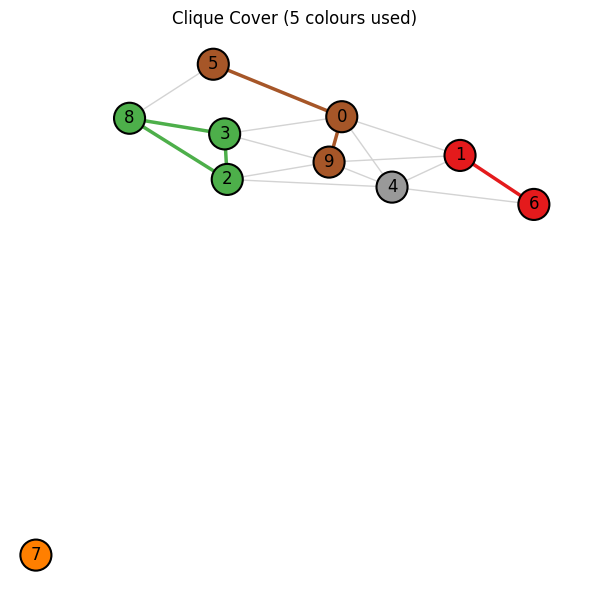

In [ ]:
# ---- Larger Random graph (unoptimal) ----

N = 10
adj_p = 0.5
n_colours = 5
A = 5.0
B = 1.0
T_start = 10.0
steps = 1000000

adjacency_matrix = generate_adjacency_matrix_undirected(N, adj_p)
x = np.random.randint(2, size=(N, n_colours))
print("x", x)

best_x, best_energy = annealing(x, adjacency_matrix, A, B, T_start, steps)

print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(best_x, A)}")
print(f"H_B (should be 0): {get_hb(best_x, adjacency_matrix, B)}")
verify_clique_cover(best_x, adjacency_matrix)
plot_clique_cover(adjacency_matrix, best_x)